In [ ]:
import pandas as pd
df_sen_result = pd.read_csv('data/temp/ieo_sentiment_results_v4.csv')

In [2]:
df_sen_result.columns

Index(['Unnamed: 0', 'Unnamed..0.1', 'Unnamed..0', 'doc_id', 'text',
       'iso_code', 'year', 'final_label', 'matched_keywords',
       'num_matched_sentences', 'sentence_id', 'sentiment_label',
       'sentiment_comment', 'r1_reasoning', 'ieo_sentiment'],
      dtype='str')

In [3]:
df_sen_result.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             50 non-null     int64  
 1   Unnamed..0.1           50 non-null     int64  
 2   Unnamed..0             50 non-null     int64  
 3   doc_id                 50 non-null     str    
 4   text                   50 non-null     str    
 5   iso_code               50 non-null     str    
 6   year                   50 non-null     int64  
 7   final_label            50 non-null     str    
 8   matched_keywords       50 non-null     str    
 9   num_matched_sentences  50 non-null     int64  
 10  sentence_id            50 non-null     str    
 11  sentiment_label        50 non-null     str    
 12  sentiment_comment      0 non-null      float64
 13  r1_reasoning           50 non-null     str    
 14  ieo_sentiment          50 non-null     str    
dtypes: float64(1), int6

In [2]:
#creating function to viz confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

def plot_confusion_matrix(true_labels, predicted_labels, title):
    labels = sorted(true_labels.unique())  # get unique label names
    cm = confusion_matrix(true_labels, predicted_labels, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,   # show label names on x axis
                yticklabels=labels)   # show label names on y axis
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [3]:
df_sen_result['sentiment_label'] = df_sen_result['sentiment_label'].str.strip().str.lower()

In [4]:
df_sen_result['ieo_sentiment'] = df_sen_result['ieo_sentiment'].str.strip().str.lower()

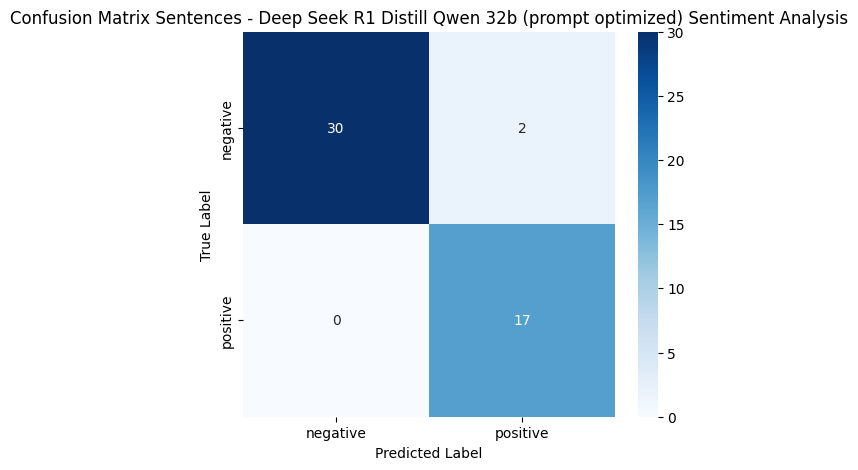

In [6]:
plot_confusion_matrix(df_sen_result['sentiment_label'],df_sen_result['ieo_sentiment'],'Confusion Matrix Sentences - Deep Seek R1 Distill Qwen 32b (prompt optimized) Sentiment Analysis')

In [9]:
def calculate_metrics(true_labels, predicted_labels, classifier_name):
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='weighted')
    recall = recall_score(true_labels, predicted_labels, average='weighted')
    f1 = f1_score(true_labels, predicted_labels, average='weighted')

    print(f"\n--- {classifier_name} Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Per class metrics
    print(f"\n--- Per Class Report ---")
    print(classification_report(true_labels, predicted_labels))
    
    return accuracy, precision, recall, f1

calculate_metrics(df_sen_result['sentiment_label'],df_sen_result['ieo_sentiment'],'Confusion Matrix Sentences - Deep Seek Sentiment v4_lui')


--- Confusion Matrix Sentences - Deep Seek Sentiment v4_lui Performance ---
Accuracy: 0.9400
Precision: 0.9621
Recall: 0.9400
F1 Score: 0.9502

--- Per Class Report ---
              precision    recall  f1-score   support

    negative       1.00      0.94      0.97        32
     neutral       0.00      0.00      0.00         0
    positive       0.89      0.94      0.92        18

    accuracy                           0.94        50
   macro avg       0.63      0.63      0.63        50
weighted avg       0.96      0.94      0.95        50



d:\UCD\LLM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\UCD\LLM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\UCD\LLM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\UCD\LLM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: 

(0.94, 0.9621052631578948, 0.94, 0.9501656495204882)

In [4]:
#create random sample of 10 positive and 10 negative sentences
positive_samples = df_sen_result[df_sen_result['sentiment_label'] == 'positive'].sample(n=10, random_state=42)
negative_samples = df_sen_result[df_sen_result['sentiment_label'] == 'negative'].sample(n=10, random_state=42)

In [5]:
positive_samples['r1_reasoning'].iloc[0]

'Okay, so I need to analyze the sentiment of the given UN speech text towards the International Economic Order (IEO). The task is to determine whether the sentiment is Positive or Negative based on the categories provided.\n\nFirst, I\'ll read the text carefully. The text says: "The rich countries have a responsibility to help poor countries take advantage of globalization and enable them to have a fairer share of the world economy by assisting them with internal reforms and by opening up markets ..."\n\nBreaking this down, the speaker is talking about rich countries helping poor countries. The key points here are:\n\n1. Rich countries have a responsibility to assist poor countries.\n2. The assistance is aimed at helping poor countries benefit from globalization.\n3. The goal is to enable a fairer share in the world economy.\n4. Methods include helping with internal reforms and opening up markets.\n\nNow, looking at the sentiment categories:\n\nPositive sentiment involves satisfaction 

In [ ]:
#save both samples to csv
positive_samples.to_csv('data/temp/positive_samples.csv', index=False)
negative_samples.to_csv('data/temp/negative_samples.csv', index=False)